# Hierarchal packaging
## This notebook quantifies sampling RBS with hierarchal packaging

In [1]:
from popsborder.scenarios import run_scenarios
from popsborder.inputs import load_configuration, load_scenario_table, load_compliance_lookup_csv
from popsborder.outputs import save_scenario_result_to_pandas

ModuleNotFoundError: No module named 'popsborder'

In [2]:
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

In [ ]:
from pathlib import Path
datadir = Path("data")
basic_config = load_configuration(datadir / "config.yml")
# Modify a directory for the plots here
plotsdir = Path("plots")
# Make sure the directory exists
plotsdir.mkdir(exist_ok=True)

# Load csv with configurations for each example scenario
contaminate_scenarios = load_scenario_table(datadir / "contaminate_examples.csv")
sample_scenarios = load_scenario_table(datadir / "sampling_examples.csv")
compliance_table = load_compliance_lookup_csv(datadir / "compliance_table.csv")
# input_consignment_data = load

In [4]:
basic_config

{'consignment': {'generation_method': 'hierarchal',
  'items_per_box': {'default': 200,
   'air': {'default': 200},
   'maritime': {'default': 200}},
  'plants_per_item': {'default': 5,
   'air': {'default': 5},
   'maritime': {'default': 5}},
  'rbs_parameter_based': {'boxes': {'min': 1, 'max': 100},
   'origins': ['Netherlands',
    'Mexico',
    'Israel',
    'Japan',
    'New Zealand',
    'India',
    'Tanzania'],
   'propagative_materials': ['Budwood/Graftwood (scion)',
    'Bulb, Corm, Rhizome, Tuberous Stem',
    'Meristem or Callus Tissue Culture (micropropagated/in vitro culture)',
    'Root cutting, crown, or clump, Tuberous Root',
    'Rooted Cutting (including air layer)',
    'Rooted Plant (including grafted)',
    'Unrooted Cutting',
    'Unrooted Plant'],
   'ports': ['Atlanta PIS',
    'Beltsville PIS',
    'Carolina PIS',
    'Guam PIS',
    'Honolulu PIS',
    'Houston PIS',
    'JFK PIS',
    'Linden PIS',
    'Los Angeles PIS',
    'Los Indios PIS',
    'Miami PIS'

## Contamination examples
Run simulation with 3 consignments using 15 different contamination approaches to show the range of contamination options available.\
Examples use three different fixed contamination rates and combinations of contamination unit (box or item) and contaminant arrangement (random, clustered continuous, or clustered random).

In [5]:
# Run contamination examples
num_consignments_1 = 3
contaminate_examples = run_scenarios(
    config=basic_config,
    scenario_table=contaminate_scenarios,
    seed=42,
    num_simulations=1,
    num_consignments=num_consignments_1,
    compliance_table=compliance_table,
    detailed=True,
)

Running scenario: contaminate example 1
Running scenario: contaminate example 2
Running scenario: contaminate example 3
Running scenario: contaminate example 4
Running scenario: contaminate example 5
Running scenario: contaminate example 6
Running scenario: contaminate example 7
Running scenario: contaminate example 8
Running scenario: contaminate example 9
Running scenario: contaminate example 10
Running scenario: contaminate example 11
Running scenario: contaminate example 12
Running scenario: contaminate example 13
Running scenario: contaminate example 14
Running scenario: contaminate example 15


In [6]:
# Separate item and inspection details from simulation totals and scenario config.
contaminate_examples_details = [i[0] for i in contaminate_examples]
contaminate_examples_results = [i[1:3] for i in contaminate_examples]

In [7]:
# Save dataframe from simulation totals and scenario config test 1.
contaminate_examples_df = save_scenario_result_to_pandas(
    contaminate_examples_results,
    config_columns=[
        "consignment name",
        "consignment/rbs_parameter_based/boxes/min",
        "consignment/rbs_parameter_based/boxes/max",
        "consignment/items_per_box/default",
        "contamination/contamination_unit",
        "contamination/contamination_rate/distribution",
        "contamination/contamination_rate/value",
        "contamination/contamination_rate/parameters",
        "contamination/arrangement",
        "contamination/clustered/distribution",
        "contamination/clustered/contaminated_units_per_cluster",
        "contamination/clustered/random/cluster_item_width",
    ],
    result_columns=[
        "avg_boxes_opened_completion",
        "avg_items_inspected_completion",
        "total_intercepted_contaminants",
        "num_inspections",
        "num_items",
        "num_boxes",
        "true_contamination_rate"
    ],
)

In [8]:
contaminate_examples_items_unstacked = [i[0] for i in contaminate_examples_details]

<Figure size 1450x1300 with 0 Axes>

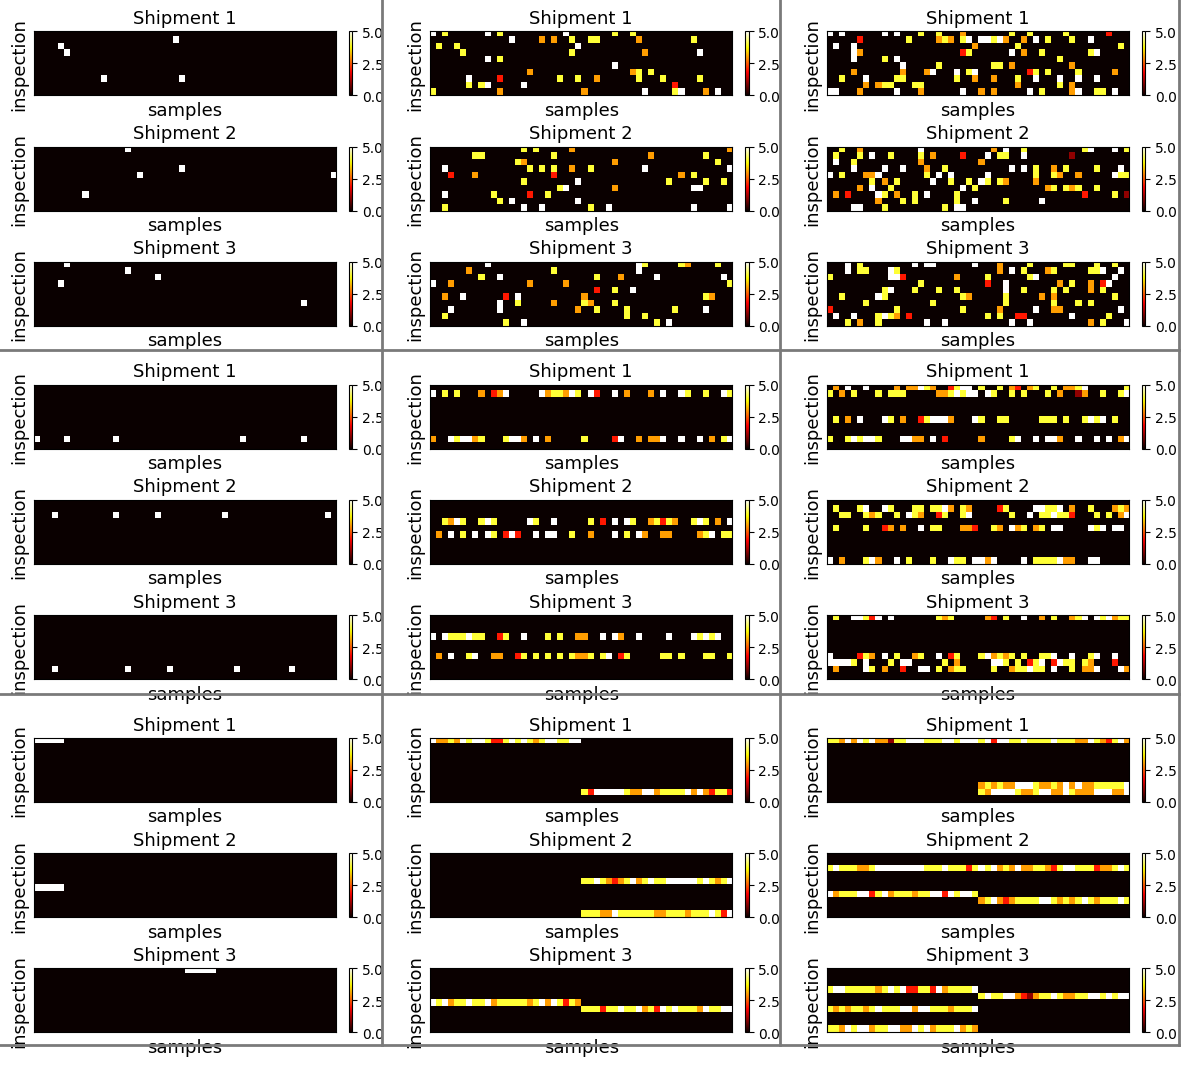

In [9]:
# Plot items for each item contamination unit scenarios
scenarios = contaminate_examples_df["consignment name"]

fig = plt.figure(figsize=(14.5, 13), constrained_layout=False)
outer_grid = fig.add_gridspec(3, 3)

num_col = 3
num_row = 3

# Define fixed scale limits
vmin = 0
vmax = np.max(np.stack(contaminate_examples_items_unstacked))

fig = plt.figure(figsize=(14.5, 13), constrained_layout=False)
outer_grid = fig.add_gridspec(num_row, num_col)

scenario_index = 0
for a in range(num_row):
    for b in range(num_col):
        inner_grid = outer_grid[a, b].subgridspec(3, 1, hspace=0.8)
        axs = inner_grid.subplots()

        contaminate_examples_items = np.stack(contaminate_examples_items_unstacked[scenario_index])
        items_by_consignment = np.vsplit(contaminate_examples_items, num_consignments_1)

        for i, consignment in enumerate(items_by_consignment):
            im = axs[i].imshow(consignment, cmap='hot', aspect='auto', vmin=vmin, vmax=vmax)
            axs[i].set_yticks([])
            axs[i].set_xticks([])
            axs[i].set_ylabel('inspection', fontsize=13)
            axs[i].set_xlabel('samples', fontsize=13)
            axs[i].set_title(f"Shipment {i + 1}", fontsize=13)

            plt.colorbar(im, ax=axs[i], fraction=0.046, pad=0.04)

        scenario_index += 1

# Drawing grid lines (optional enhancement)
from pylab import *
axs[i].plot([0.365, 0.365], [0.1, 0.905], color='#7A7A7A', lw=2,
         transform=gcf().transFigure, clip_on=False)
axs[i].plot([0.64, 0.64], [0.1, 0.905], color='#7A7A7A', lw=2,
         transform=gcf().transFigure, clip_on=False)
axs[i].plot([0.09, 0.915], [.37, .37], color='#7A7A7A', lw=2,
         transform=gcf().transFigure, clip_on=False)
axs[i].plot([0.09, 0.915], [.635, .635], color='#7A7A7A', lw=2,
         transform=gcf().transFigure, clip_on=False)
axs[i].plot([0.09, 0.915], [0.905, 0.905], color='#7A7A7A', lw=2,
         transform=gcf().transFigure, clip_on=False)
axs[i].plot([0.09, 0.915], [0.1, 0.1], color='#7A7A7A', lw=2,
         transform=gcf().transFigure, clip_on=False)
axs[i].plot([0.915, 0.915], [0.1, 0.905], color='#7A7A7A', lw=2,
         transform=gcf().transFigure, clip_on=False)
axs[i].plot([0.09, 0.09], [0.1, 0.905], color='#7A7A7A', lw=2,
         transform=gcf().transFigure, clip_on=False)

plt.show()
fig.savefig(plotsdir / "contam_examples_items_heatmap.jpg", dpi=800)


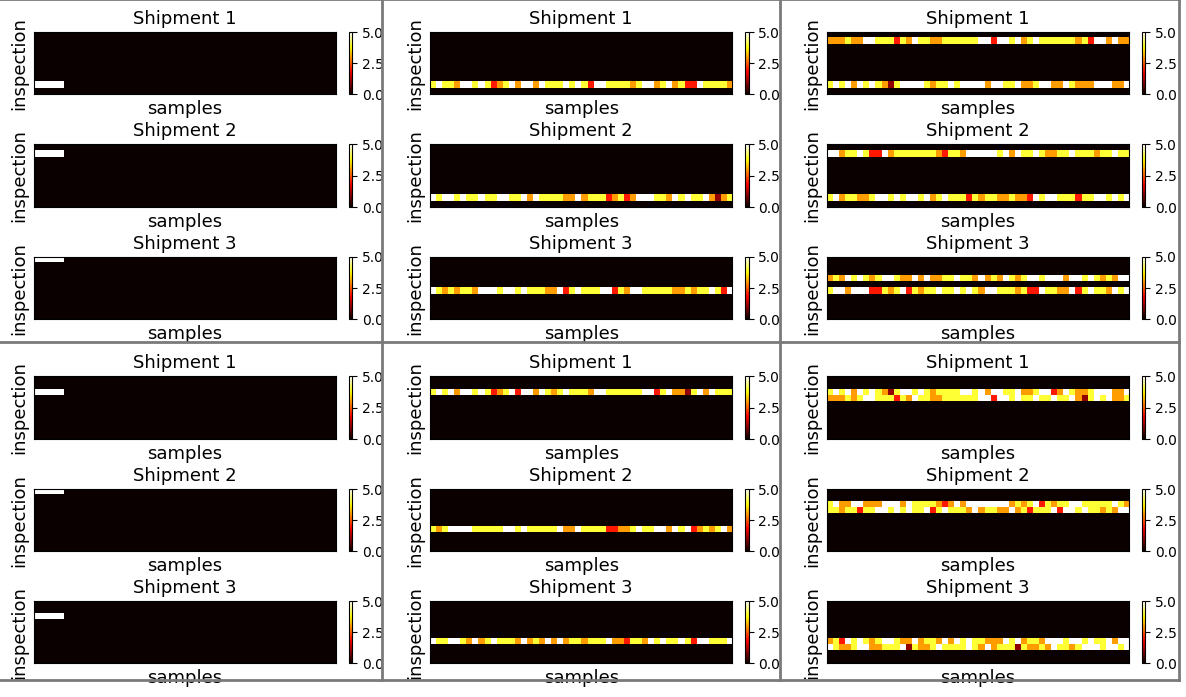

In [10]:
# Plot items for each box contamination unit scenarios
scenarios = contaminate_examples_df["consignment name"]

fig = plt.figure(figsize=(14.5, 8.2), constrained_layout=False)

num_col = 3
num_row = 2
outer_grid = fig.add_gridspec(num_row, num_col)

# Define fixed scale limits
vmin = 0
vmax = np.max(np.stack(contaminate_examples_items_unstacked))


# Starting with the first box contamination unit scenario
scenario_index = 9
for a in range(num_row):
    for b in range(num_col):
        inner_grid = outer_grid[a, b].subgridspec(3, 1, hspace=0.8)
        axs = inner_grid.subplots()

        contaminate_examples_items = np.stack(contaminate_examples_items_unstacked[scenario_index])
        items_by_consignment = np.vsplit(contaminate_examples_items, num_consignments_1)

        for i, consignment in enumerate(items_by_consignment):
            im = axs[i].imshow(consignment, cmap='hot', aspect='auto', vmin=vmin, vmax=vmax)
            axs[i].set_yticks([])
            axs[i].set_xticks([])
            axs[i].set_ylabel('inspection', fontsize=13)
            axs[i].set_xlabel('samples', fontsize=13)
            axs[i].set_title(f"Shipment {i + 1}", fontsize=13)

            # Add colorbar for each subplot to show scale
            plt.colorbar(im, ax=axs[i], fraction=0.046, pad=0.04)

        scenario_index += 1


from pylab import *
axs[i].plot([0.365, 0.365], [0.09, 0.92], color='#7A7A7A', lw=2,
         transform=gcf().transFigure, clip_on=False)
axs[i].plot([0.64, 0.64], [0.09, 0.92], color='#7A7A7A', lw=2,
         transform=gcf().transFigure, clip_on=False)
axs[i].plot([0.09, 0.915], [.502, .502], color='#7A7A7A', lw=2,
         transform=gcf().transFigure, clip_on=False)
axs[i].plot([0.09, 0.915], [0.92, 0.92], color='#7A7A7A', lw=2,
         transform=gcf().transFigure, clip_on=False)
axs[i].plot([0.09, 0.915], [0.09, 0.09], color='#7A7A7A', lw=2,
         transform=gcf().transFigure, clip_on=False)
axs[i].plot([0.915, 0.915], [0.09, 0.92], color='#7A7A7A', lw=2,
         transform=gcf().transFigure, clip_on=False)
axs[i].plot([0.09, 0.09], [0.09, 0.92], color='#7A7A7A', lw=2,
         transform=gcf().transFigure, clip_on=False)

plt.show()

fig.savefig(plotsdir / "contam_examples_boxes.jpg", dpi=800)

In [11]:
contaminate_examples_df

,consignment name,consignment/rbs_parameter_based/boxes/min,consignment/rbs_parameter_based/boxes/max,consignment/items_per_box/default,contamination/contamination_unit,contamination/contamination_rate/distribution,contamination/contamination_rate/value,contamination/contamination_rate/parameters,contamination/arrangement,contamination/clustered/distribution,contamination/clustered/contaminated_units_per_cluster,contamination/clustered/random/cluster_item_width,avg_boxes_opened_completion,avg_items_inspected_completion,total_intercepted_contaminants,num_inspections,num_items,num_boxes,true_contamination_rate
0,item 0.01 random,10,10,50,item,fixed_value,0.01,None,random,None,NaN,NaN,8.666667,433.333333,75.0,3.0,1500.0,30.0,0.01
1,item 0.1 random,10,10,50,item,fixed_value,0.10,None,random,None,NaN,NaN,10.000000,500.000000,600.0,3.0,1500.0,30.0,0.10
2,item 0.2 random,10,10,50,item,fixed_value,0.20,None,random,None,NaN,NaN,10.000000,500.000000,1200.0,3.0,1500.0,30.0,0.20
3,item 0.01 clustered random,10,10,50,item,fixed_value,0.01,None,clustered,random,25.0,50.0,8.666667,433.333333,50.0,3.0,1500.0,30.0,0.01
4,item 0.1 clustered random,10,10,50,item,fixed_value,0.10,None,clustered,random,25.0,50.0,10.000000,500.000000,600.0,3.0,1500.0,30.0,0.10
5,item 0.2 clustered random,10,10,50,item,fixed_value,0.20,None,clustered,random,25.0,50.0,10.000000,500.000000,1200.0,3.0,1500.0,30.0,0.20
6,item 0.01 clustered continuous,10,10,50,item,fixed_value,0.01,None,clustered,continuous,25.0,NaN,8.666667,433.333333,75.0,3.0,1500.0,30.0,0.01
7,item 0.1 clustered continuous,10,10,50,item,fixed_value,0.10,None,clustered,continuous,25.0,NaN,10.000000,500.000000,600.0,3.0,1500.0,30.0,0.10
8,item 0.2 clustered continuous,10,10,50,item,fixed_value,0.20,None,clustered,continuous,25.0,NaN,10.000000,500.000000,1200.0,3.0,1500.0,30.0,0.20
9,box 0.01 random,10,10,50,box,fixed_value,0.01,None,random,None,NaN,NaN,8.666667,433.333333,75.0,3.0,1500.0,30.0,0.01


## Sampling examples
Run simulation with 3 consignments using 12 different sampling approaches to show the range of inspection options available.\
Examples use two different fixed sampling rates and combinations of inspection unit (box or item) and sample selection method (convenience, random, interval cluster, or random cluster).

In [12]:
# Run sampling examples
num_consignments = 3
sample_examples = run_scenarios(
    config=basic_config,
    scenario_table=sample_scenarios,
    seed=42,
    num_simulations=1,
    num_consignments=num_consignments,
    compliance_table=compliance_table,
    detailed=True,
)

Running scenario: sample example 1
Running scenario: sample example 2
Running scenario: sample example 3
Running scenario: sample example 4
Running scenario: sample example 5
Running scenario: sample example 6
Running scenario: sample example 7
Running scenario: sample example 8
Running scenario: sample example 9
Running scenario: sample example 10
Running scenario: sample example 11
Running scenario: sample example 12


In [13]:
# Separate item and inspection details from simulation totals and scenario config.
sample_examples_details = [i[0] for i in sample_examples]
sample_examples_results = [i[1:3] for i in sample_examples]

In [14]:
# Save simulation totals and scenario config to dataframe.
sample_examples_df = save_scenario_result_to_pandas(
    sample_examples_results,
    config_columns=[
        "inspection name",
        "consignment/rbs_parameter_based/boxes/min",
        "consignment/rbs_parameter_based/boxes/max",
        "consignment/items_per_box/default",
        "inspection/unit",
        "inspection/sample_strategy",
        "inspection/proportion/value",
        "inspection/hypergeometric/detection_level",
        "inspection/selection_strategy",
    ],
    result_columns=[
        "avg_boxes_opened_completion",
        "avg_items_inspected_completion",
        "total_intercepted_contaminants",
        "num_inspections",
        "num_items",
        "num_boxes",
        "num_plants",
        "true_contamination_rate",
    ],
)

In [15]:
item_example_indexes = [0,6,1,7,2,8,3,9]
box_example_indexes = [4,10,5,11]

In [16]:
sample_examples_inspected_indexes = [i[1] for i in sample_examples_details]

In [17]:
item_scenarios = sample_examples_df.iloc[item_example_indexes,:]
item_inspected_indexes = [sample_examples_inspected_indexes[i] for i in item_example_indexes]
box_scenarios = sample_examples_df.iloc[box_example_indexes,:]
box_inspected_indexes = [sample_examples_inspected_indexes[i] for i in box_example_indexes]

num_items_per_consignment = 500
num_boxes_per_consignment = 10


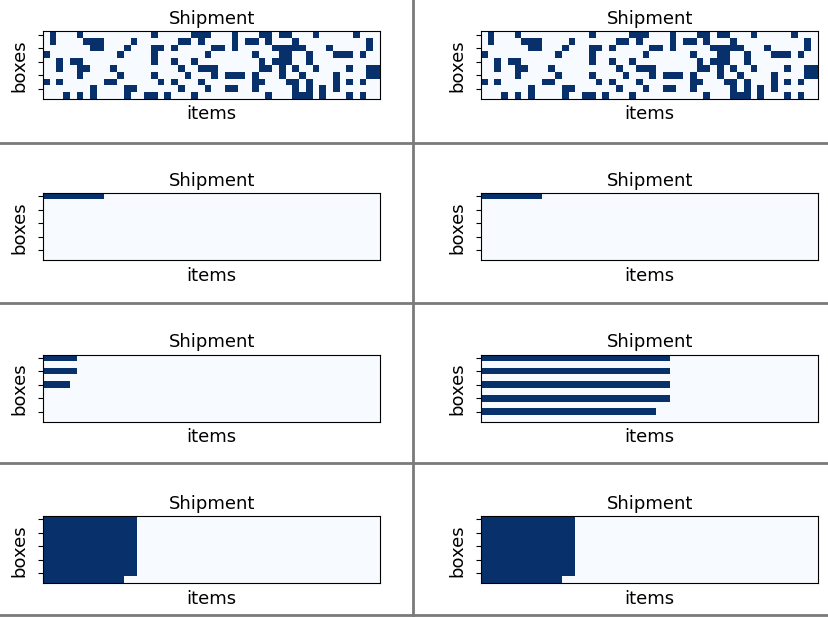

In [18]:
fig = plt.figure(figsize=(10,8), constrained_layout=False)
outer_grid = fig.add_gridspec(4, 2, hspace=0.4, wspace=0.3, top=0.86)

scenario_index = 0
for a in range(4):
    for b in range(2):
        # gridspec inside gridspec
        inner_grid = outer_grid[a, b].subgridspec(1, 1)
        axs = inner_grid.subplots()  # Create all subplots for the inner grid.
        for i in range(num_consignments):
            indexes = np.zeros(num_items_per_consignment, dtype=int)
            inpsected = item_inspected_indexes[scenario_index][i]
            np.put(indexes, inpsected, 1)
            indexes = np.array_split(indexes, num_boxes_per_consignment)
            axs.matshow(indexes, cmap='Blues', vmin=0, vmax=1)
            axs.set_yticklabels([])
            axs.tick_params(labeltop=False, top=False, bottom=False)
            axs.set_ylabel('boxes', fontsize=13)
            axs.set_xlabel('items', fontsize=13)
            axs.set_title("Shipment", fontsize=13)
        scenario_index += 1


from pylab import *
axs.plot([0.495, 0.495], [0.1, 0.88], color='#7A7A7A', lw=2,
         transform=gcf().transFigure, clip_on=False)
axs.plot([0.07, 0.93], [.49, .49], color='#7A7A7A', lw=2,
         transform=gcf().transFigure, clip_on=False)
axs.plot([0.07, 0.93], [0.88, 0.88], color='#7A7A7A', lw=2,
         transform=gcf().transFigure, clip_on=False)
axs.plot([0.07, 0.93], [0.1, 0.1], color='#7A7A7A', lw=2,
         transform=gcf().transFigure, clip_on=False)
axs.plot([0.93, 0.93], [0.1, 0.88], color='#7A7A7A', lw=2,
         transform=gcf().transFigure, clip_on=False)
axs.plot([0.07, 0.07], [0.1, 0.88], color='#7A7A7A', lw=2,
         transform=gcf().transFigure, clip_on=False)
axs.plot([0.07, 0.93], [0.69, 0.69], color='#7A7A7A', lw=2,
         transform=gcf().transFigure, clip_on=False)
axs.plot([0.07, 0.93], [0.29, 0.29], color='#7A7A7A', lw=2,
         transform=gcf().transFigure, clip_on=False)


plt.show()


fig.savefig(plotsdir / "sample_examples_items.jpg", dpi=800)

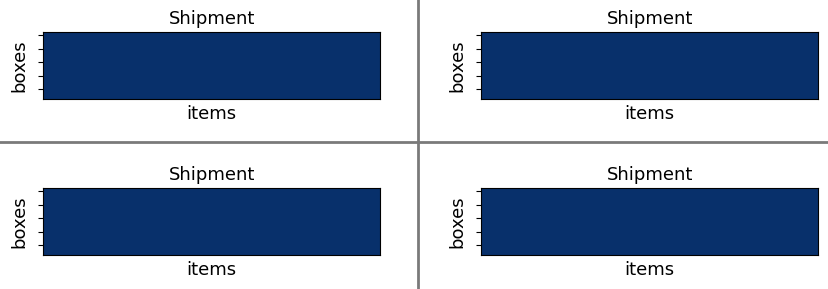

In [19]:
fig = plt.figure(figsize=(10,4), constrained_layout=False)
outer_grid = fig.add_gridspec(2, 2, hspace=0.3, wspace=0.3, top=0.83, bottom=0.14)

scenario_index = 0
for a in range(2):
    for b in range(2):
        # gridspec inside gridspec
        inner_grid = outer_grid[a, b].subgridspec(1, 1)
        axs = inner_grid.subplots()  # Create all subplots for the inner grid.
        for i in range(num_consignments):
            indexes = np.zeros(num_items_per_consignment, dtype=int)
            inpsected = box_inspected_indexes[scenario_index][i]
            np.put(indexes, inpsected, 1)
            indexes = np.array_split(indexes, num_boxes_per_consignment)
            axs.matshow(indexes, cmap='Blues', vmin=0, vmax=1)
            axs.set_yticklabels([])
            axs.tick_params(labeltop=False, top=False, bottom=False)
            axs.set_ylabel('boxes', fontsize=13)
            axs.set_xlabel('items', fontsize=13)
            axs.set_title("Shipment", fontsize=13)
        scenario_index += 1


from pylab import *
axs.plot([0.5, 0.5], [0.1, 0.88], color='#7A7A7A', lw=2,
         transform=gcf().transFigure, clip_on=False)
axs.plot([0.07, 0.93], [.49, .49], color='#7A7A7A', lw=2,
         transform=gcf().transFigure, clip_on=False)
axs.plot([0.07, 0.93], [0.88, 0.88], color='#7A7A7A', lw=2,
         transform=gcf().transFigure, clip_on=False)
axs.plot([0.07, 0.93], [0.1, 0.1], color='#7A7A7A', lw=2,
         transform=gcf().transFigure, clip_on=False)
axs.plot([0.93, 0.93], [0.1, 0.88], color='#7A7A7A', lw=2,
         transform=gcf().transFigure, clip_on=False)
axs.plot([0.07, 0.07], [0.1, 0.88], color='#7A7A7A', lw=2,
         transform=gcf().transFigure, clip_on=False)

plt.show()

fig.savefig(plotsdir / "sample_examples_boxes.jpg", dpi=800)

In [20]:
sample_examples_df

,inspection name,consignment/rbs_parameter_based/boxes/min,consignment/rbs_parameter_based/boxes/max,consignment/items_per_box/default,inspection/unit,inspection/sample_strategy,inspection/proportion/value,inspection/hypergeometric/detection_level,inspection/selection_strategy,avg_boxes_opened_completion,avg_items_inspected_completion,total_intercepted_contaminants,num_inspections,num_items,num_boxes,num_plants,true_contamination_rate
0,item proportion random,10,10,50,items,rbs,0.04,None,random,8.000000,58.333333,675.0,3.0,1500.0,30.0,7500.0,0.1
1,item proportion convenience,10,10,50,items,rbs,0.04,None,convenience,1.000000,17.000000,450.0,3.0,1500.0,30.0,7500.0,0.1
2,item proportion interval cluster,10,10,50,items,rbs,0.04,None,cluster,3.333333,17.000000,450.0,3.0,1500.0,30.0,7500.0,0.1
3,item proportion random cluster,10,10,50,items,rbs,0.04,None,cluster,6.000000,58.333333,450.0,3.0,1500.0,30.0,7500.0,0.1
4,box proportion random,10,10,50,boxes,rbs,0.10,None,random,10.000000,500.000000,675.0,3.0,1500.0,30.0,7500.0,0.1
5,box proportion convenience,10,10,50,boxes,rbs,0.10,None,convenience,10.000000,500.000000,675.0,3.0,1500.0,30.0,7500.0,0.1
6,item proportion random,10,10,50,items,rbs,0.20,None,random,8.000000,58.333333,675.0,3.0,1500.0,30.0,7500.0,0.1
7,item proportion convenience,10,10,50,items,rbs,0.20,None,convenience,1.000000,17.000000,450.0,3.0,1500.0,30.0,7500.0,0.1
8,item proportion interval cluster,10,10,50,items,rbs,0.20,None,cluster,4.333333,101.333333,675.0,3.0,1500.0,30.0,7500.0,0.1
9,item proportion random cluster,10,10,50,items,rbs,0.20,None,cluster,7.666667,101.333333,675.0,3.0,1500.0,30.0,7500.0,0.1
